In [19]:
import numpy as np 
import pandas as pd 
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Data Scrap

## yfinance approach: init db, insert data, update db, add new 

In [7]:
import sqlite3
from datetime import datetime, timedelta
import yfinance as yf


In [11]:
DB_NAME = 'stocks.db'


def initialize_database():
    """
    Create a SQLite database and the stock_data table.
    """

    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS stock_data (
            stock TEXT,
            date TEXT,
            open REAL,
            high REAL,
            low REAL,
            close REAL,
            volume INTEGER,
            dividends REAL,
            stock_splits REAL,
            PRIMARY KEY (stock, date)
        )
    """)
    conn.commit()
    conn.close()


def insert_data(ticker_symbol, data):
    """
    Insert historical data for a given stock into the database.
    """

    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    for _, row in data.iterrows():
        cursor.execute("""
            INSERT OR IGNORE INTO stock_data 
            (stock, date, open, high, low, close, volume, dividends, stock_splits)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
        """, (
            ticker_symbol,
            row['Date'].strftime('%Y-%m-%d') if isinstance(row['Date'], (datetime, pd.Timestamp)) else row['Date'],
            row['Open'],
            row['High'],
            row['Low'],
            row['Close'],
            row['Volume'],
            row['Dividends'],
            row['Stock Splits']
        ))
    conn.commit()
    conn.close()


def fetch_missing_data(ticker_symbol, start_date):
    """
    Fetch missing data for a stock from a given start date.
    """

    ticker = yf.Ticker(ticker_symbol)
    data = ticker.history(start=start_date)
    flat_data = data.reset_index()
    flat_data.insert(0, 'stock', ticker_symbol)
    return flat_data


def update_database():
    """
    Check if stock data is up to date and fetch missing data if needed.
    """

    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute("SELECT DISTINCT stock FROM stock_data")
    stocks = cursor.fetchall()
    stocks = [stock[0] for stock in stocks]
    
    for stock in stocks:
        cursor.execute("""
            SELECT MAX(date) FROM stock_data WHERE stock = ?
        """, (stock,))
        result = cursor.fetchone()
        last_date = result[0]
        
        if last_date:
            last_date = datetime.strptime(last_date, '%Y-%m-%d').date()
            if last_date < datetime.now().date() - timedelta(days=1):
                print(f"Updating data for {stock}...")
                missing_start = last_date + timedelta(days=1)
                new_data = fetch_missing_data(stock, missing_start)
                insert_data(stock, new_data)
    
    conn.close()


def add_new_stock(ticker_symbol):
    """
    Add a new stock's data to the database.
    """

    print(f"Fetching data for {ticker_symbol}...")
    ticker = yf.Ticker(ticker_symbol)
    historical_data = ticker.history(period='max')
    flat_data = historical_data.reset_index()
    flat_data.insert(0, 'stock', ticker_symbol)
    insert_data(ticker_symbol, flat_data)


def get_data_from_db(ticker_symbol, start_date, end_date):
    # TODO: if start_date is == 'full' then get all the historicla data -> date <= end_date

    """
    Fetch data for a given ticker symbol and date range from the database.

    Parameters:
        ticker_symbol (str): The stock symbol to fetch data for.
        start_date (str): The start date in 'YYYY-MM-DD' format.
        end_date (str): The end date in 'YYYY-MM-DD' format.
    """

    conn = sqlite3.connect(DB_NAME)
    query = """
        SELECT * FROM stock_data
        WHERE stock = ? AND date BETWEEN ? AND ?
        ORDER BY date ASC
    """
    data = pd.read_sql_query(query, conn, params=(ticker_symbol, start_date, end_date))
    conn.close()

    # data['date'] = pd.to_datetime(data['date'])
    return data

In [38]:
# initialize_database()
# add_new_stock('NVDA')
update_database()

Updating data for AAPL...
Updating data for MSFT...
Updating data for NVDA...


# Preprocessing

## Download input from DB 

In [49]:
df_test = get_data_from_db('NVDA', '2019-01-01', '2025-01-02')

In [50]:
df_test

,stock,date,open,high,low,close,volume,dividends,stock_splits
0,NVDA,2019-01-02,3.239713,3.434136,3.225082,3.378090,508752000,0.0,0.0
1,NVDA,2019-01-03,3.317828,3.351803,3.166556,3.173995,705552000,0.0,0.0
2,NVDA,2019-01-04,3.247152,3.415536,3.216402,3.377346,585620000,0.0,0.0
3,NVDA,2019-01-07,3.434631,3.593096,3.383298,3.556145,709160000,0.0,0.0
4,NVDA,2019-01-08,3.637733,3.639965,3.394953,3.467613,786016000,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1505,NVDA,2024-12-24,140.000000,141.899994,138.649994,140.220001,105157000,0.0,0.0
1506,NVDA,2024-12-26,139.699997,140.850006,137.729996,139.929993,116205600,0.0,0.0
1507,NVDA,2024-12-27,138.550003,139.020004,134.710007,137.009995,170291000,0.0,0.0
1508,NVDA,2024-12-30,134.830002,140.270004,134.020004,137.490005,167734700,0.0,0.0


## Split and Normzlize 

In [51]:
def split_data(data, train_ratio=0.8):
    """
    Split data into training and validation sets using train_test_split.

    Parameters:
        data (DataFrame): The stock data.
        train_ratio (float): The proportion of data to use for training.
    """

    train_data, validation_data = train_test_split(data, train_size=train_ratio, shuffle=False)
    return train_data, validation_data


def normalize_data(train_data, validation_data):
    """
    Normalize training and validation sets using MinMaxScaler.

    Parameters:
        train_data (DataFrame): Training data.
        validation_data (DataFrame): Validation data.
    """
    columns_to_normalize = ['open', 'high', 'low', 'close']

    scaler = MinMaxScaler(feature_range=(0, 1))
    
    scaler.fit(train_data[columns_to_normalize])
    
    train_data_normalized = train_data.copy()
    validation_data_normalized = validation_data.copy()
    
    train_data_normalized[columns_to_normalize] = scaler.transform(train_data[columns_to_normalize])
    validation_data_normalized[columns_to_normalize] = scaler.transform(validation_data[columns_to_normalize])
    
    
    return train_data_normalized, validation_data_normalized, scaler

In [52]:
train_df_test, validation_df_test = split_data(df_test)


In [53]:
train_df_test

,stock,date,open,high,low,close,volume,dividends,stock_splits
0,NVDA,2019-01-02,3.239713,3.434136,3.225082,3.378090,508752000,0.0,0.0
1,NVDA,2019-01-03,3.317828,3.351803,3.166556,3.173995,705552000,0.0,0.0
2,NVDA,2019-01-04,3.247152,3.415536,3.216402,3.377346,585620000,0.0,0.0
3,NVDA,2019-01-07,3.434631,3.593096,3.383298,3.556145,709160000,0.0,0.0
4,NVDA,2019-01-08,3.637733,3.639965,3.394953,3.467613,786016000,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1203,NVDA,2023-10-12,46.759630,47.591321,46.312797,46.927567,481325000,0.0,0.0
1204,NVDA,2023-10-13,46.942559,47.098503,45.263182,45.444115,474115000,0.0,0.0
1205,NVDA,2023-10-16,45.046270,46.207837,44.895325,46.077888,375099000,0.0,0.0
1206,NVDA,2023-10-17,43.983662,44.737383,42.464225,43.921684,812333000,0.0,0.0


In [54]:
validation_df_test

,stock,date,open,high,low,close,volume,dividends,stock_splits
1208,NVDA,2023-10-19,42.795105,43.280924,41.866449,42.085369,501233000,0.0,0.0
1209,NVDA,2023-10-20,41.874443,42.454230,41.062744,41.371632,477266000,0.0,0.0
1210,NVDA,2023-10-23,41.213695,43.231947,40.929800,42.959045,478530000,0.0,0.0
1211,NVDA,2023-10-24,43.061005,43.680774,42.675150,43.646786,401463000,0.0,0.0
1212,NVDA,2023-10-25,43.381879,43.633788,41.539565,41.763481,398379000,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1505,NVDA,2024-12-24,140.000000,141.899994,138.649994,140.220001,105157000,0.0,0.0
1506,NVDA,2024-12-26,139.699997,140.850006,137.729996,139.929993,116205600,0.0,0.0
1507,NVDA,2024-12-27,138.550003,139.020004,134.710007,137.009995,170291000,0.0,0.0
1508,NVDA,2024-12-30,134.830002,140.270004,134.020004,137.490005,167734700,0.0,0.0


In [55]:
train_df_test_scaled, validation_df_test_scaled, scaler = normalize_data(train_df_test, validation_df_test)

In [56]:
train_df_test_scaled

,stock,date,open,high,low,close,volume,dividends,stock_splits
0,NVDA,2019-01-02,0.000000,0.001756,0.001279,0.004422,508752000,0.0,0.0
1,NVDA,2019-01-03,0.001664,0.000000,0.000000,0.000000,705552000,0.0,0.0
2,NVDA,2019-01-04,0.000158,0.001359,0.001089,0.004405,585620000,0.0,0.0
3,NVDA,2019-01-07,0.004151,0.005146,0.004736,0.008279,709160000,0.0,0.0
4,NVDA,2019-01-08,0.008477,0.006145,0.004990,0.006361,786016000,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1203,NVDA,2023-10-12,0.926873,0.943446,0.942691,0.947896,481325000,0.0,0.0
1204,NVDA,2023-10-13,0.930769,0.932937,0.919758,0.915758,474115000,0.0,0.0
1205,NVDA,2023-10-16,0.890382,0.913942,0.911721,0.929488,375099000,0.0,0.0
1206,NVDA,2023-10-17,0.867751,0.882584,0.858604,0.882775,812333000,0.0,0.0


In [57]:
validation_df_test_scaled

,stock,date,open,high,low,close,volume,dividends,stock_splits
1208,NVDA,2023-10-19,0.842437,0.851523,0.845544,0.842993,501233000,0.0,0.0
1209,NVDA,2023-10-20,0.822830,0.833894,0.827984,0.827530,477266000,0.0,0.0
1210,NVDA,2023-10-23,0.808757,0.850479,0.825079,0.861920,478530000,0.0,0.0
1211,NVDA,2023-10-24,0.848101,0.860051,0.863213,0.876820,401463000,0.0,0.0
1212,NVDA,2023-10-25,0.854934,0.859049,0.838402,0.836019,398379000,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1505,NVDA,2024-12-24,2.912675,2.954662,2.960142,2.969023,105157000,0.0,0.0
1506,NVDA,2024-12-26,2.906285,2.932270,2.940041,2.962740,116205600,0.0,0.0
1507,NVDA,2024-12-27,2.881793,2.893243,2.874058,2.899480,170291000,0.0,0.0
1508,NVDA,2024-12-30,2.802566,2.919901,2.858983,2.909880,167734700,0.0,0.0


# Model

## Input (windows) preparation

In [ ]:
# TODO: build sequences, try different ranges (values) of sequences and see the performance 
"""
time relationships: long and shord memory 
"""

In [58]:
def create_sequences(close_values, window_size=5):
    """
    Create sequences of close values for LSTM input.

    Parameters:
        close_values (array-like): The 'close' values from the dataset.
        window_size (int): The size of the sliding window (sequence length).
    """

    X, y = [], []
    for i in range(len(close_values) - window_size):
        X.append(close_values[i:i + window_size])
        y.append(close_values[i + window_size])
    return np.array(X), np.array(y)


In [59]:
X_train, y_train = create_sequences(train_df_test_scaled['close'].values, window_size=5)
X_val, y_val = create_sequences(validation_df_test_scaled['close'].values, window_size=5)

In [64]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))

In [65]:
X_train.shape, X_val.shape

((1203, 5, 1), (297, 5, 1))

## LSTM

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam



# Tests

## Operating on created DB

In [ ]:
def print_top_records():
    """
    Fetch and print the top 10 records from the stock_data table.
    """
    
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()

    query = "SELECT * FROM stock_data LIMIT 100;"
    cursor.execute(query)  

    records = cursor.fetchall()
    column_names = [description[0] for description in cursor.description]
    df = pd.DataFrame(records, columns=column_names)
    print(df)
    
    conn.close()

print_top_records()

   stock        date      open      high       low     close      volume  \
0   MSFT  1986-03-13  0.054485  0.062498  0.054485  0.059827  1031788800   
1   MSFT  1986-03-14  0.059827  0.063032  0.059827  0.061963   308160000   
2   MSFT  1986-03-17  0.061963  0.063566  0.061963  0.063032   133171200   
3   MSFT  1986-03-18  0.063032  0.063566  0.060895  0.061429    67766400   
4   MSFT  1986-03-19  0.061429  0.061963  0.059827  0.060361    47894400   
..   ...         ...       ...       ...       ...       ...         ...   
95  MSFT  1986-07-29  0.065169  0.065703  0.062498  0.063566    14054400   
96  MSFT  1986-07-30  0.063566  0.063566  0.059293  0.061429    26409600   
97  MSFT  1986-07-31  0.061429  0.061963  0.060895  0.060895    15638400   
98  MSFT  1986-08-01  0.060895  0.061429  0.059827  0.060361    12902400   
99  MSFT  1986-08-04  0.060361  0.060361  0.058758  0.060361    12441600   

    dividends  stock_splits  
0         0.0           0.0  
1         0.0           0.0

## Train and Val vs Normalized Train and Val 

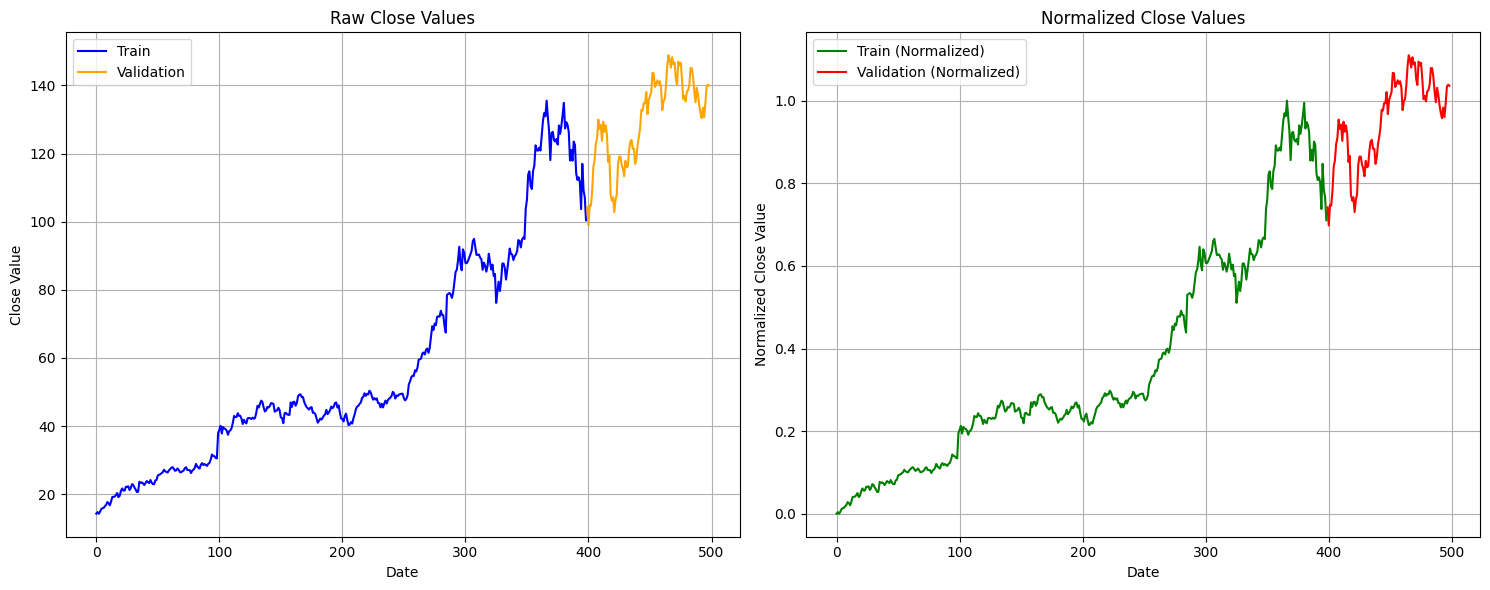

In [37]:
import matplotlib.pyplot as plt

def plot_raw_and_normalized(train_data, validation_data, train_normalized, validation_normalized):
    """
    Create a subplot with raw and normalized close values for train and validation datasets.
    """

    fig, axs = plt.subplots(1, 2, figsize=(15, 6))

    axs[0].plot(train_data.index, train_data['close'], label='Train', color='blue')
    axs[0].plot(validation_data.index, validation_data['close'], label='Validation', color='orange')
    axs[0].set_title("Raw Close Values")
    axs[0].set_xlabel("Date")
    axs[0].set_ylabel("Close Value")
    axs[0].legend()
    axs[0].grid(True)

    axs[1].plot(train_normalized.index, train_normalized['close'], label='Train (Normalized)', color='green')
    axs[1].plot(validation_normalized.index, validation_normalized['close'], label='Validation (Normalized)', color='red')
    axs[1].set_title("Normalized Close Values")
    axs[1].set_xlabel("Date")
    axs[1].set_ylabel("Normalized Close Value")
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_raw_and_normalized(train_df_test, validation_df_test, train_df_test_scaled, validation_df_test_scaled)